# Dependencies

In [1]:
from prepare_time_boroughs import prepare_yearly_boroughs, prepare_quarterly_boroughs, prepare_monthly_boroughs
from forecasting_class import Forecast
import pandas as pd
import matplotlib.pyplot as plt
import geopandas
import geopandas as gpd

from pathlib import Path
ROOT = Path('/Users/josh/Library/CloudStorage/GoogleDrive-jeverer@gmail.com/My Drive/London Sport/london_sport2')
list(ROOT.rglob('*.shp'))

/opt/anaconda3/envs/london/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


[PosixPath('/Users/josh/Library/CloudStorage/GoogleDrive-jeverer@gmail.com/My Drive/London Sport/london_sport2/src/stream_1/forecasting/borough_amplitude.shp')]

In [2]:
df_year = prepare_yearly_boroughs()
df_quarter = prepare_quarterly_boroughs()
df_month = prepare_monthly_boroughs()

PREPARING YEARLY DATA...
COMPLETE
PREPARING QUARTERLY DATA...
COMPLETE
PREPARING MONTHLY DATA...
COMPLETE


# Seasonality Analysis

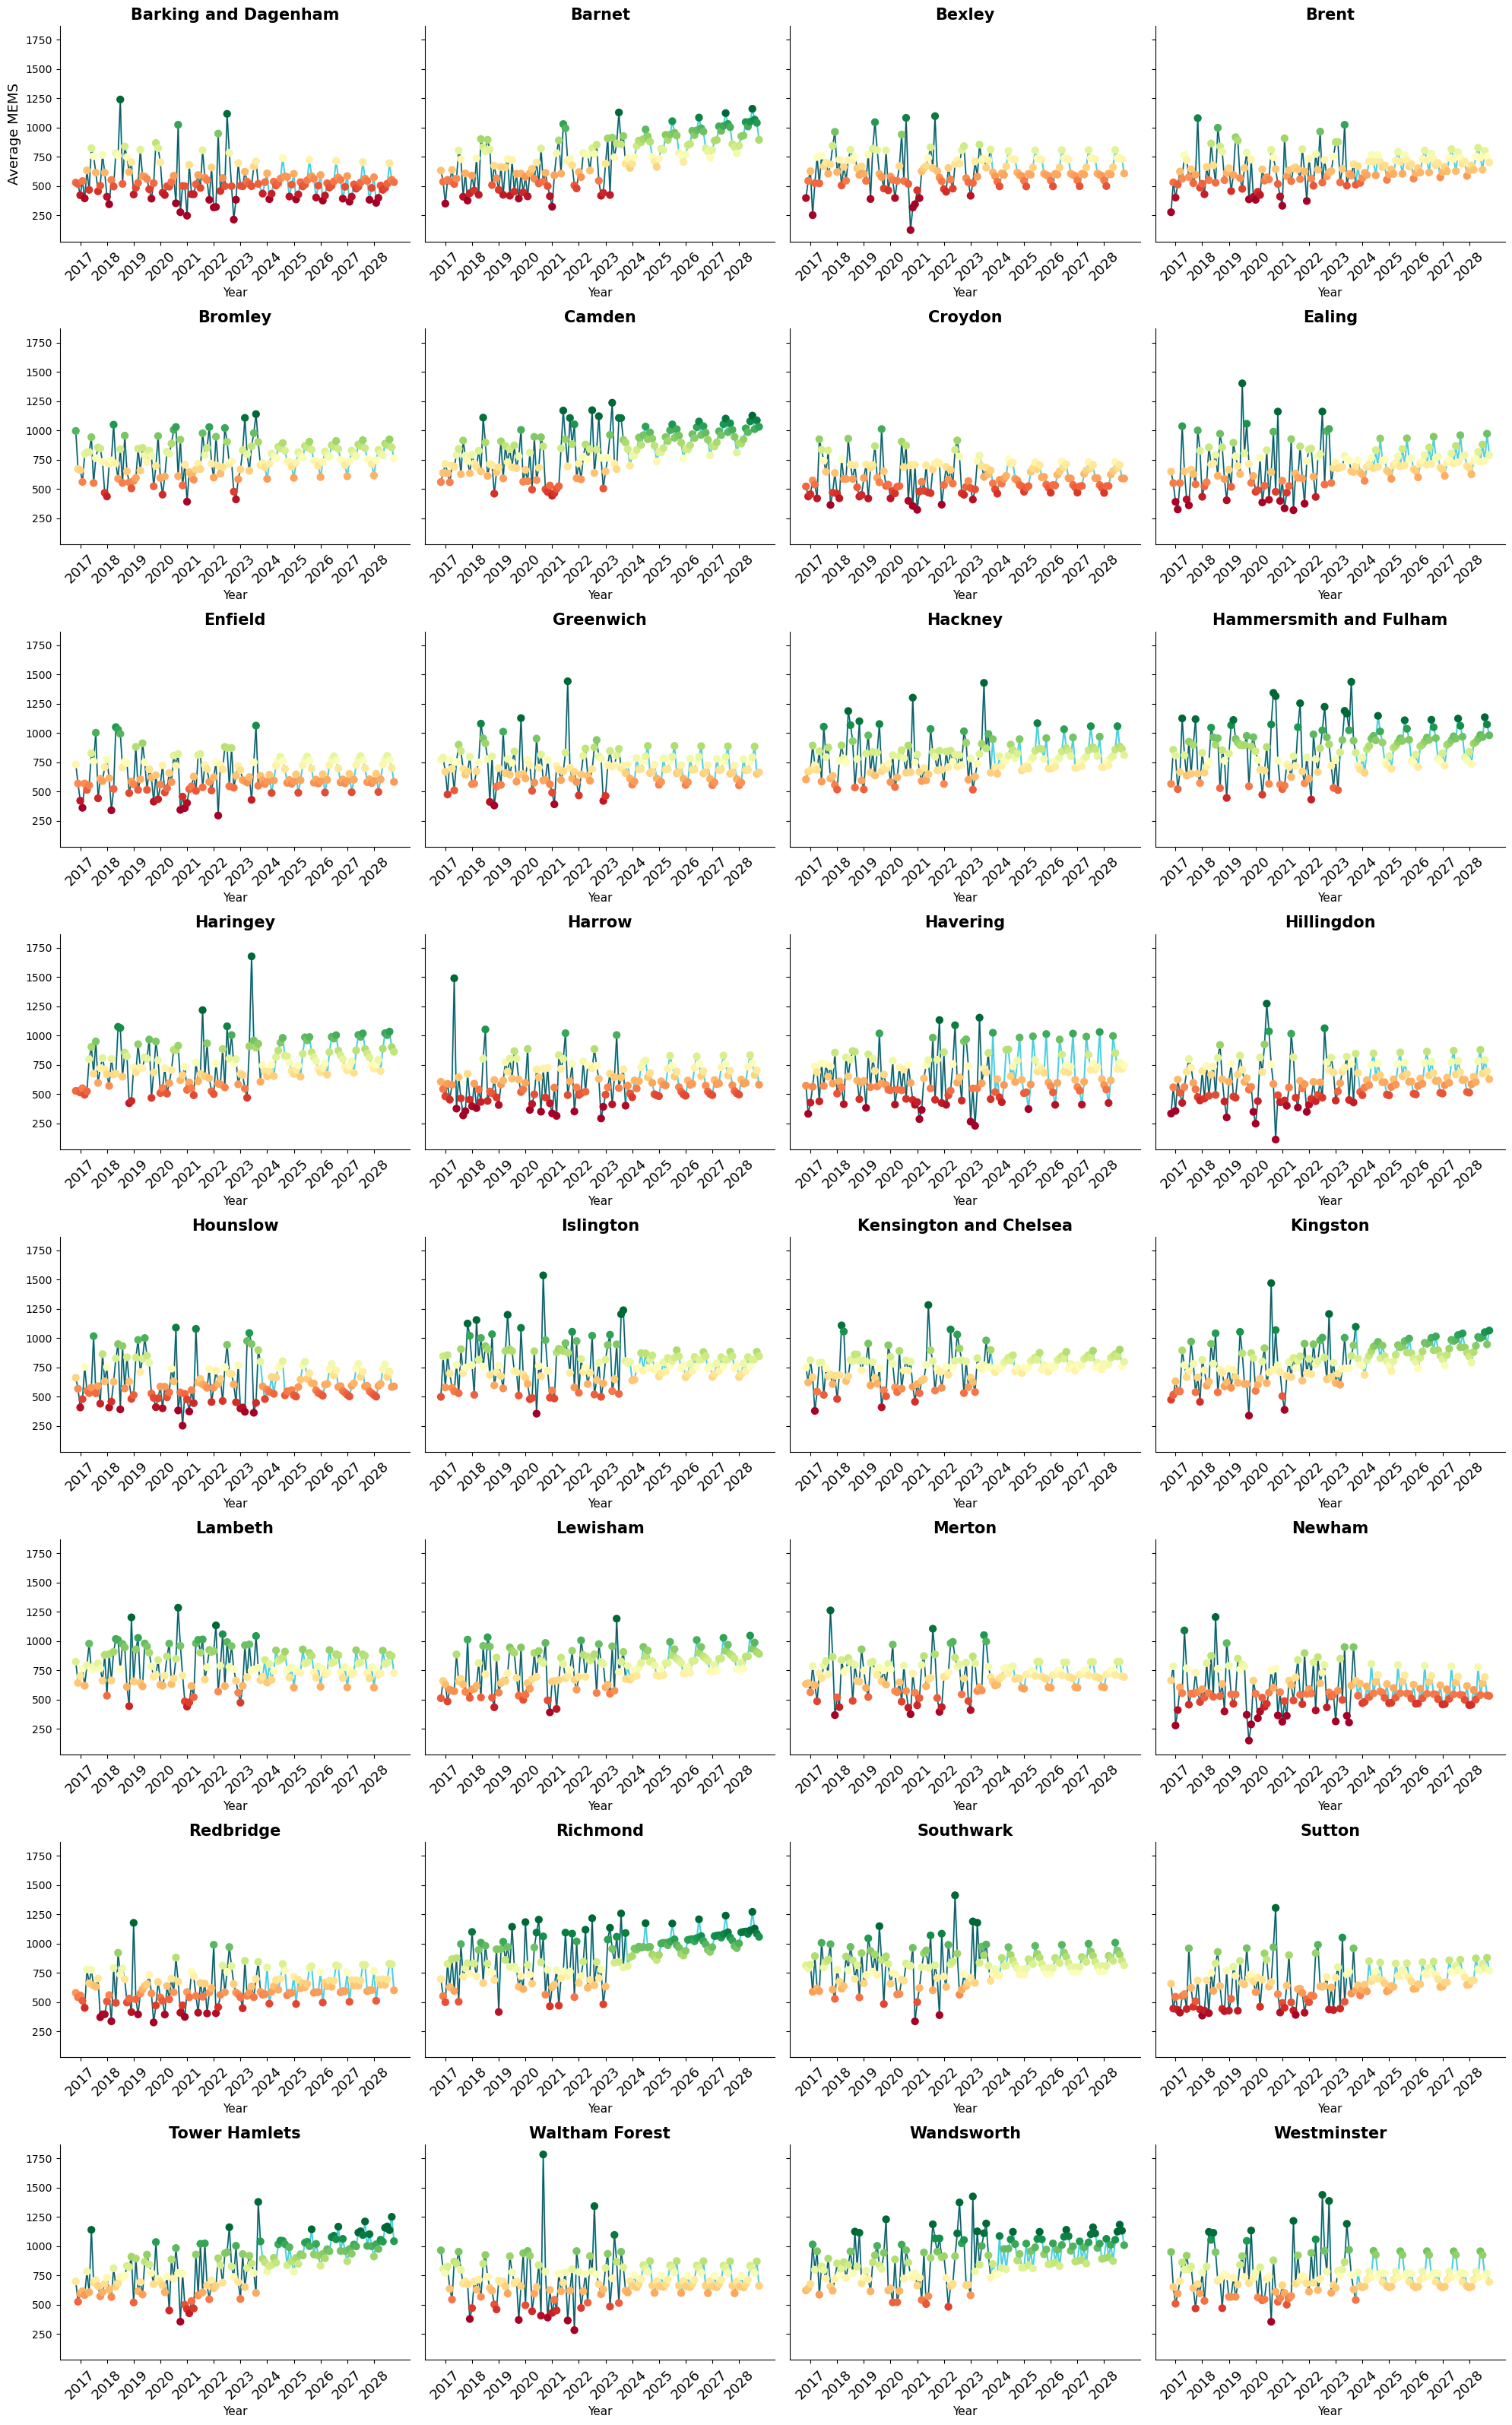

In [3]:
smb = Forecast(df_month, forecast_steps=60, group_col='LA_Name')
smb.sarima()
smb.get_mae('sarima')
smb.plot()

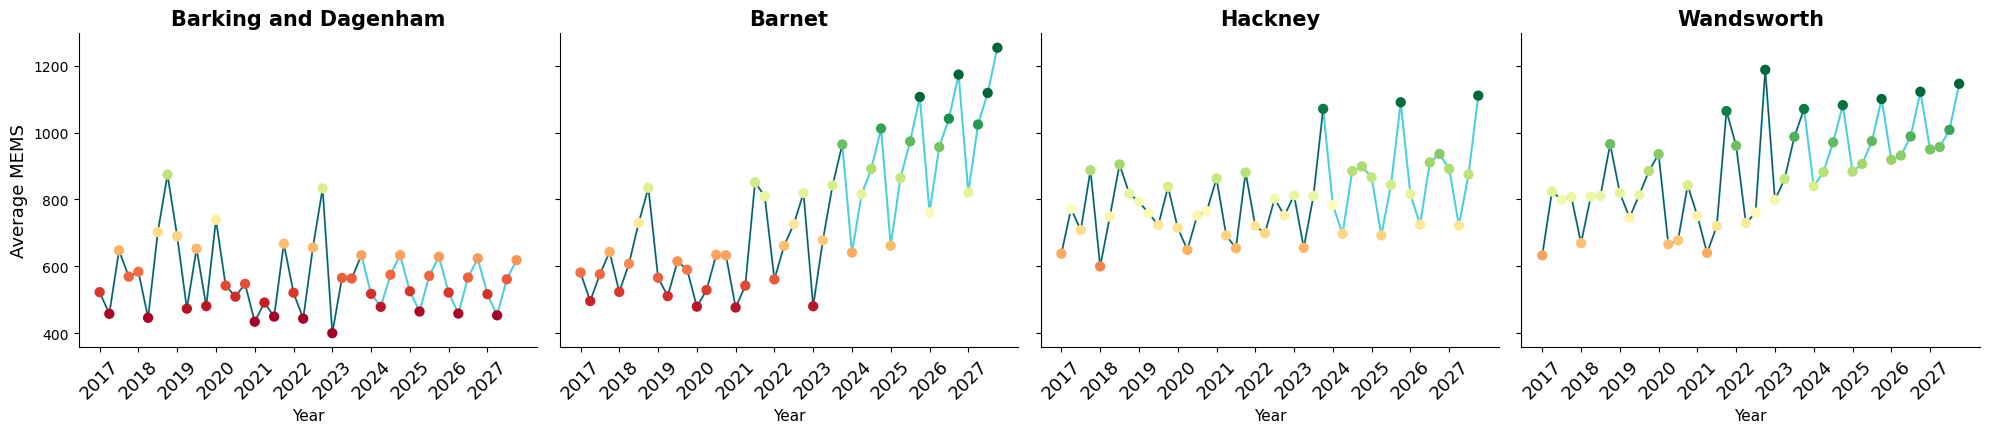

In [4]:
sqb = Forecast(df_quarter, forecast_steps=16, group_col='LA_Name')
sqb.sarima()
sqb.get_mae('sarima')
sqb.plot(show=['Barking and Dagenham', 'Barnet', 'Hackney', 'Wandsworth'])
#print('\n')
#sqb.plot()

# Amplitude Analysis

In [5]:
url = "https://raw.githubusercontent.com/radoi90/housequest-data/master/london_boroughs.geojson"
gdf = gpd.read_file(url)
print(gdf.columns.tolist())

['name', 'color', 'geometry']


In [6]:
summer = df_month[df_month['month'].isin([6,7,8])].groupby('LA_Name')['MEMS7_ALL'].mean()
winter = df_month[df_month['month'].isin([12,1,2])].groupby('LA_Name')['MEMS7_ALL'].mean()
amplitude = (summer - winter).reset_index()
amplitude.columns = ['LA_Name', 'amplitude']

amplitude['LA_Name'] = amplitude['LA_Name'].replace({
    'Kingston': 'Kingston upon Thames',
    'Richmond': 'Richmond upon Thames'
})

gdf_merged = gdf.merge(amplitude, left_on='name', right_on='LA_Name', how='left')

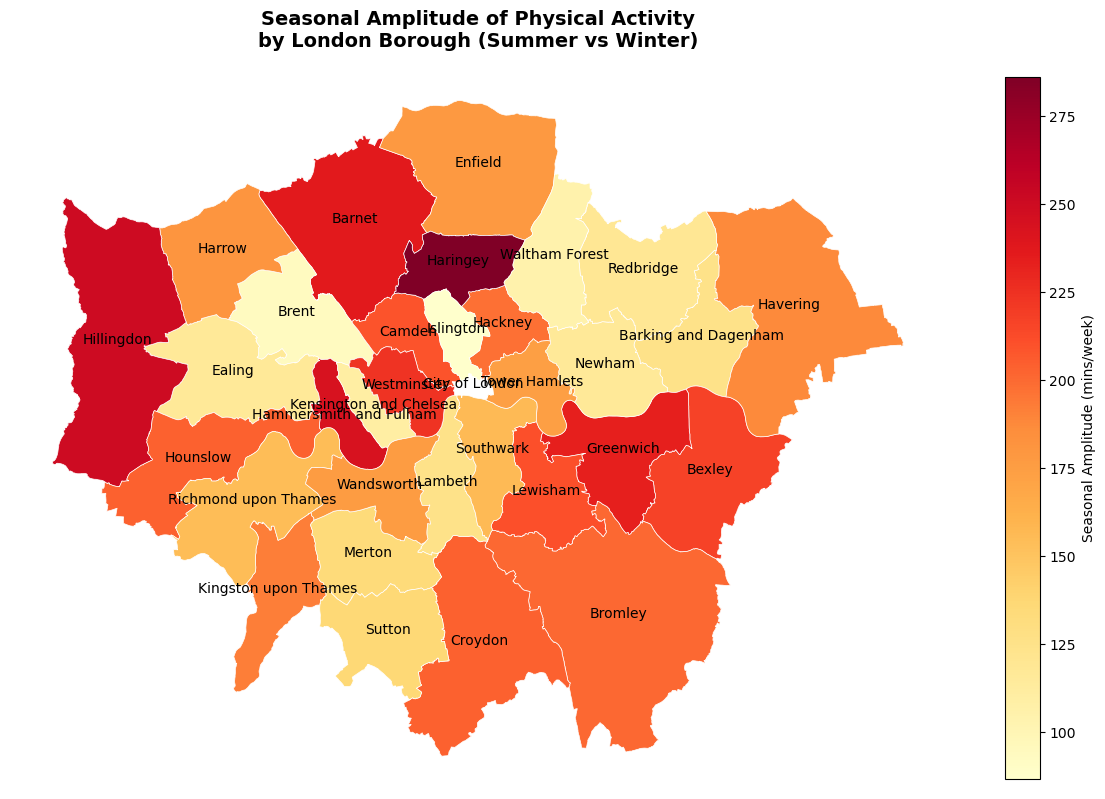

In [7]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib import cm

fig, ax = plt.subplots(figsize=(12, 12))

gdf_merged.plot(
    column='amplitude',
    ax=ax,
    cmap='YlOrRd',
    legend=True,
    legend_kwds={'label': 'Seasonal Amplitude (mins/week)', 'shrink': 0.6},
    edgecolor='white',
    linewidth=0.5
)

for _, row in gdf_merged.iterrows():
    ax.annotate(
        row['name'],
        xy=(row.geometry.centroid.x, row.geometry.centroid.y),
        ha='center', fontsize=10, color='black'
    )

ax.set_title('Seasonal Amplitude of Physical Activity\nby London Borough (Summer vs Winter)', 
             fontsize=14, fontweight='bold', pad=15)
ax.axis('off')
plt.tight_layout()
plt.savefig('choropleth_amplitude.png', dpi=150, bbox_inches='tight')
plt.show()

gdf_merged[['name', 'amplitude']].to_csv('borough_amplitude.csv', index=False)
gdf_merged.to_file('borough_amplitude.shp')

In [8]:
borough_maes = sqb.sarima_forecast[['LA_Name', 'mae']].sort_values('mae')

best_3 = borough_maes.head(3)['LA_Name'].tolist()
worst_3 = borough_maes.tail(3)['LA_Name'].tolist()
print("Best:", best_3)
print("Worst:", worst_3)

Best: ['Barking and Dagenham', 'Bromley', 'Islington']
Worst: ['Kingston', 'Haringey', 'Hillingdon']
